----

## Carga de librerías

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import graph_objects as go
from statsmodels.stats.proportion import proportions_ztest
from pathlib import Path
import sqlite3

In [70]:
def data_load(file_names):
    """
    Carga múltiples archivos CSV desde la carpeta 'raw' y los devuelve en un diccionario.
    
    Parámetros:
    - file_names (list): Una lista con los nombres de los archivos (ej. ['datos1.csv', 'datos2.csv'])
    """
    current_folder = Path.cwd()
    root_folder = current_folder.parent
    raw_data = root_folder / "data" / "raw"
    

    loaded_datasets = {}
  
    for index, file in enumerate(file_names):
        file_path = raw_data / file 
        key_name = f"data_{index}"
        loaded_datasets[key_name] = pd.read_csv(file_path, sep='\t')
        
        print(f"Archivo '{file}' cargado exitosamente como '{key_name}'")

    return loaded_datasets

In [71]:
data = data_load(['logs_exp_us.csv'])
data = data['data_0']

Archivo 'logs_exp_us.csv' cargado exitosamente como 'data_0'


# Preprocesamiento de datos




In [72]:
def clean_event_data(df: pd.DataFrame):
    """
   Perform cleaning, column formatting, and generation of  variables for the event dataset.
    """
    data = df.copy()
    columns_map = {
        data.columns[0]: 'event_name',
        data.columns[1]: 'device_id_hash',
        data.columns[2]: 'event_timestamp',
        data.columns[3]: 'exp_id'
    }
    data.rename(columns=columns_map, inplace=True)
    data.drop_duplicates(inplace=True)


    data['event_timestamp'] = pd.to_datetime(data['event_timestamp'], unit='s')
    data['date_hour'] = data['event_timestamp'].dt.to_period('h').dt.to_timestamp()
    data['date'] = data['event_timestamp'].dt.date

    print("--- Data Summary ---")
    print(f"\nTotal registers: {len(data)}\n")
    print(f"Null values:\n{data.isnull().sum()}\n")
    print(f"Data describe \n{data.describe(include='all')}\n")
    print(f"Sample (5) of registers \n{data.sample(5)}\n")
    
    return data

In [73]:
df_a = clean_event_data(data)

--- Data Summary ---

Total registers: 243713

Null values:
event_name         0
device_id_hash     0
event_timestamp    0
exp_id             0
date_hour          0
date               0
dtype: int64

Data describe 
              event_name  device_id_hash      event_timestamp         exp_id  \
count             243713    2.437130e+05               243713  243713.000000   
unique                 5             NaN                  NaN            NaN   
top     MainScreenAppear             NaN                  NaN            NaN   
freq              119101             NaN                  NaN            NaN   
mean                 NaN    4.627963e+18  2019-08-04 10:19:17     247.022161   
min                  NaN    6.888747e+15  2019-07-25 04:43:36     246.000000   
25%                  NaN    2.372212e+18  2019-08-02 14:36:45     246.000000   
50%                  NaN    4.623192e+18  2019-08-04 11:51:00     247.000000   
75%                  NaN    6.932517e+18  2019-08-06 06:56:24    

# Automatización en la creación de la base de datos usando SQLite

In [74]:
def save_to_sqlite(df: pd.DataFrame, db_name: str = "ab_test_data.db", table_name: str = "cleaned_events"):
    """
    Save the DataFrame in an SQLite database within the data/processed/ folder.
    Parámetros: 
    df: tipo DataFrame 
    db_name : Data base name ab_test_data.db
    table_name: Table name
    """
    current_folder = Path.cwd()
    root_folder = current_folder.parent
    destiniy_folder = root_folder/"data"/"processed"
        
    db_path = destiniy_folder / db_name
    
    try:
        with sqlite3.connect(db_path) as conn:
            df_to_save = df.copy()
            if 'date' in df_to_save.columns:
                df_to_save['date'] = df_to_save['date'].astype(str)
            df_to_save.to_sql(table_name, conn, if_exists='replace', index=False)
            print(f"\n✅ Dataframe saved") 
    except Exception as e:
        print(f"❌ Error: {e}")

In [75]:
save_to_sqlite(df_a)


✅ Dataframe saved


## Visualizaciones 


In [76]:
def generate_all_visualizations(df_a, target_date):
    """
    Genera y muestra una serie de visualizaciones de eventos y usuarios.
    Parámetros:
    - df_a: DataFrame principal con los eventos.
    - data_filtered: DataFrame filtrado para el embudo.
    """

    
    
    
    data_counts = df_a.groupby('event_name')['device_id_hash'].agg([
        ('total_events', 'count'),
        ('unique_users', 'nunique')
    ]).reset_index().sort_values(by='total_events', ascending=False)


    data_filtered = df_a[df_a['event_timestamp'] >= target_date]
    
    plt.figure(figsize=(14, 8))
    sns.set_style("darkgrid")
    
    
    for i, row in data_counts.iterrows():
        plt.barh(row['event_name'], row['total_events'], color='royalblue', alpha=0.6, 
                 label='Total Events' if i == 0 else "")
        plt.barh(row['event_name'], row['unique_users'], color='teal', alpha=0.6, 
                 label='Unique Users' if i == 0 else "")

    plt.xlabel('Conteo')
    plt.ylabel('Nombre del evento')
    plt.title('Total de eventos y usuarios únicos por evento')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

  
    plt.figure(figsize=(15, 6))
    counts = df_a.groupby('device_id_hash')['event_name'].count()
    counts.hist(bins=150, color='teal')
    plt.xlabel('Número de eventos')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de los eventos')
    plt.xlim(0, 300)

    # Creación de gráfico con serie de tiempo. 
    plt.figure(figsize=(15, 6))
    data_ev = df_a.groupby('date')['event_name'].count()
    data_ev.plot(kind='line', marker='o')
    plt.title('Evolución de los datos de tiempo')
    plt.xlabel('Fecha')
    plt.ylabel('Número de eventos')

   # Creación del embudo de eventos.
    data_counts_filtered = data_filtered.groupby('event_name')['device_id_hash'].agg([
        ('total_events', 'count'),
        ('unique_users', 'nunique')
    ]).reset_index().sort_values(by='total_events', ascending=False)


    fig = go.Figure(go.Funnel(
        y = data_counts_filtered['event_name'],
        x = data_counts_filtered['unique_users'],
        marker=dict(color=['royalblue', 'cornflowerblue', 'royalblue', 'cornflowerblue', 'royalblue'])
    ))
    fig.update_layout(title='Embudo de usuarios por eventos')
    
    print(f" Se filtraron los datos usando la fecha correspondiente a: {target_date}\n")
    data_loss = (1-(data_filtered['event_name'].count() / df_a['event_name'].count()))*100
    print(f'Al filtrar los datos, se pierden {data_loss:.4f}% de los datos.')
    
   
    fig.show()   
    plt.show()  


 Se filtraron los datos usando la fecha correspondiente a: 2019-07-31

Al filtrar los datos, se pierden 0.3266% de los datos.


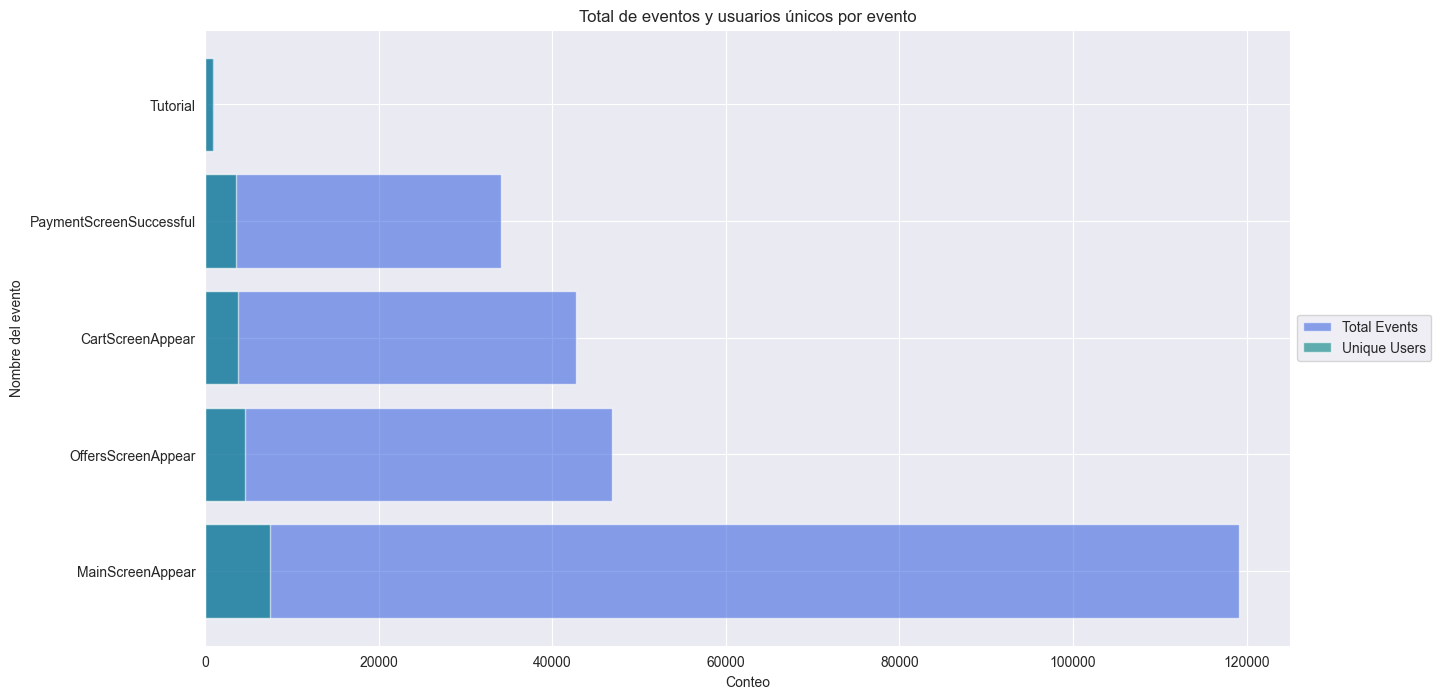

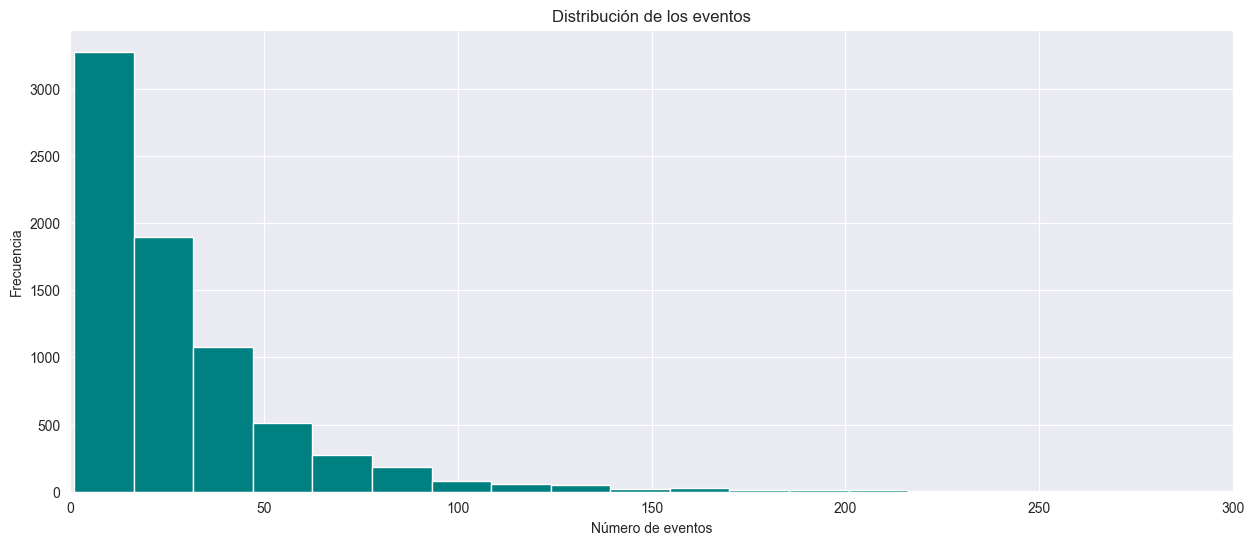

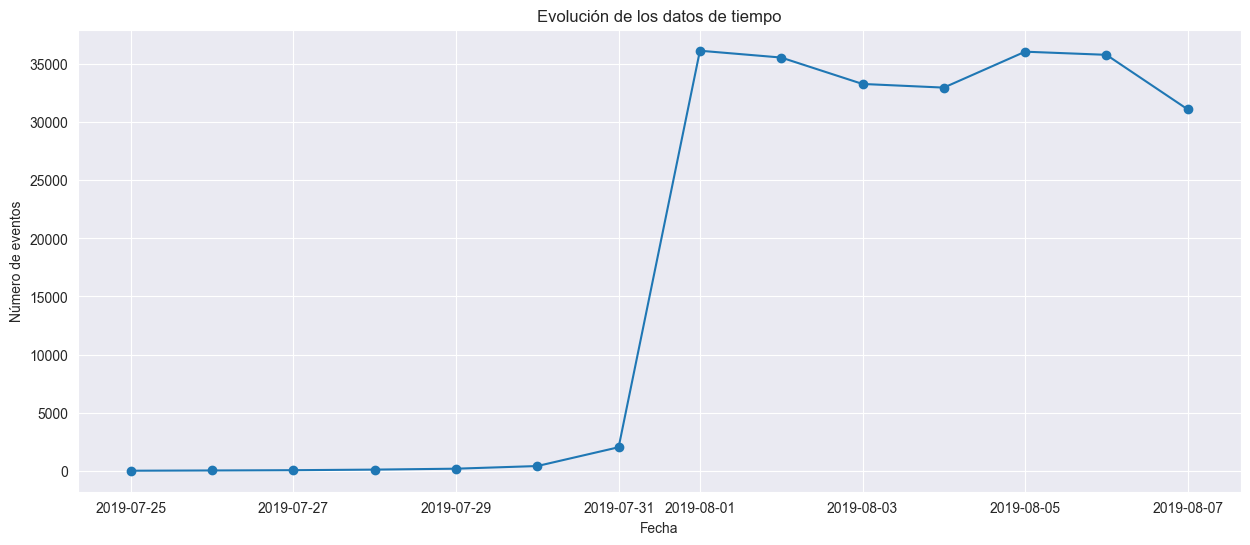

In [77]:
generate_all_visualizations(df_a, '2019-07-31')

## Análisis de los resultados de los experimentos

### Planteamiento de hipótesis:

H0: No existe diferencia estadística significativa entre las proporciones de los grupos analizados.

H1: Existe diferencia estadística significativa entre las proporciones de los grupos analizados

### Declaración de función para calcular las pruebas estadísticas

In [78]:
# Declaración de función para calcular las pruebas estadísticas

def compare_groups(data_set, group_col_1, group_col_2, col_count, group_1, group_2, conversion_from, conversion_to, p_value_set=0.05, num_tests=6, target_date = '2019-07-31'):
    """
    Esta función calcula las pruebas estadísticas para comparar las proporciones de dos grupos de datos
    basándose en statsmodels.stats.proportion.proportions_ztest y aplica la corrección de Bonferroni si es necesario.
    """
    # Filtrado de datos
    data_set = data_set[data_set['event_timestamp'] >= target_date]

    # Ajuste del nivel de significancia usando la corrección de Bonferroni
    adjusted_p_value_set = p_value_set / num_tests
    
    count = np.array([
        data_set[(data_set[group_col_1] == group_1) & (data_set[group_col_2] == conversion_to)][col_count].nunique(),
        data_set[(data_set[group_col_1] == group_2) & (data_set[group_col_2] == conversion_to)][col_count].nunique()
    ])

    nobs = np.array([
        data_set[(data_set[group_col_1] == group_1) & (data_set[group_col_2] == conversion_from)][col_count].nunique(),
        data_set[(data_set[group_col_1] == group_2) & (data_set[group_col_2] == conversion_from)][col_count].nunique()
    ])

    stat, pval = proportions_ztest(count, nobs)

    print('El p_valor de la prueba es:', np.round(pval, 3))
    print()

    # Interpretación del resultado de la prueba
    if pval < adjusted_p_value_set:
        print('Existe diferencia estadística significativa entre las proporciones de los grupos analizados')
    else:
        print('No existe diferencia estadística significativa entre las proporciones de los grupos analizados')



### Pruebas estadísticas usando grupos control

In [79]:
# Comparación de los pasos MainScreenAppear a OffersScreenAppear
compare_groups(df_a, 'exp_id', 'event_name', 'device_id_hash', 246, 247, 'MainScreenAppear', 'OffersScreenAppear')

El p_valor de la prueba es: 0.306

No existe diferencia estadística significativa entre las proporciones de los grupos analizados


In [80]:
# Comparación de los pasos OffersScreenAppear a CartScreenAppear
compare_groups(df_a, 'exp_id', 'event_name', 'device_id_hash', 246, 247, 'OffersScreenAppear', 'CartScreenAppear')

El p_valor de la prueba es: 0.535

No existe diferencia estadística significativa entre las proporciones de los grupos analizados


In [81]:
# Compración de los pasos CartScreenAppear a PaymentScreenSuccessful
compare_groups(df_a, 'exp_id', 'event_name', 'device_id_hash', 246, 247, 'CartScreenAppear', 'PaymentScreenSuccessful')

El p_valor de la prueba es: 0.213

No existe diferencia estadística significativa entre las proporciones de los grupos analizados


### Comparaciones entre grupo control y grupo experimental

In [82]:
# Comparación de los pasos MainScreenAppear a OffersScreenAppear
compare_groups(df_a, 'exp_id', 'event_name', 'device_id_hash', 246, 248, 'MainScreenAppear', 'OffersScreenAppear')

El p_valor de la prueba es: 0.283

No existe diferencia estadística significativa entre las proporciones de los grupos analizados


In [83]:
# Comparación de los pasos OffersScreenAppear a CartScreenAppear
compare_groups(df_a, 'exp_id', 'event_name', 'device_id_hash', 246, 248, 'OffersScreenAppear', 'CartScreenAppear')

El p_valor de la prueba es: 0.258

No existe diferencia estadística significativa entre las proporciones de los grupos analizados


In [84]:
# Compración de los pasos CartScreenAppear a PaymentScreenSuccessful
compare_groups(df_a, 'exp_id', 'event_name', 'device_id_hash', 246, 248, 'CartScreenAppear', 'PaymentScreenSuccessful')

El p_valor de la prueba es: 0.242

No existe diferencia estadística significativa entre las proporciones de los grupos analizados
